<a href="https://colab.research.google.com/github/Mehnaz-Bashir/Human-Activity-Recognition/blob/main/notebooks/04_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [5]:
import zipfile

zip_path = "/content/UCI HAR Dataset.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [8]:
import pandas as pd
import os
from collections import Counter

dataset_path = "/content/UCI HAR Dataset"

features = pd.read_csv(
    os.path.join(dataset_path, "features.txt"),
    sep=r"\s+",
    header=None,
    names=["Index", "Feature"]
)

In [9]:
feature_names = features["Feature"].values

counter = Counter()
unique_features = []

for col in feature_names:
    counter[col] += 1
    if counter[col] == 1:
        unique_features.append(col)
    else:
        unique_features.append(f"{col}_{counter[col]}")

In [10]:
X_train = pd.read_csv(
    os.path.join(dataset_path, "train", "X_train.txt"),
    sep=r"\s+",
    header=None,
    names=unique_features
)

X_test = pd.read_csv(
    os.path.join(dataset_path, "test", "X_test.txt"),
    sep=r"\s+",
    header=None,
    names=unique_features
)

In [11]:
y_train = pd.read_csv(
    os.path.join(dataset_path, "train", "y_train.txt"),
    header=None,
    names=["Activity"]
)

y_test = pd.read_csv(
    os.path.join(dataset_path, "test", "y_test.txt"),
    header=None,
    names=["Activity"]
)

In [12]:
subject_train = pd.read_csv(
    os.path.join(dataset_path, "train", "subject_train.txt"),
    header=None,
    names=["Subject"]
)

subject_test = pd.read_csv(
    os.path.join(dataset_path, "test", "subject_test.txt"),
    header=None,
    names=["Subject"]
)


In [13]:
train_df = pd.concat([subject_train, y_train, X_train], axis=1)
test_df = pd.concat([subject_test, y_test, X_test], axis=1)

har_df = pd.concat([train_df, test_df], ignore_index=True)

In [14]:
activity_labels = pd.read_csv(
    os.path.join(dataset_path, "activity_labels.txt"),
    sep=r"\s+",
    header=None,
    names=["Activity", "Activity_Name"]
)

activity_map = dict(zip(activity_labels.Activity,
                        activity_labels.Activity_Name))

har_df["Activity_Name"] = har_df["Activity"].map(activity_map)

In [15]:
har_df.shape

(10299, 564)

In [16]:
X = har_df.drop(columns=["Subject", "Activity", "Activity_Name"])
y = har_df["Activity_Name"]

In [17]:
print("X:", X.shape)
print("y:", y.shape)

X: (10299, 561)
y: (10299,)


In [18]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [19]:
for i, label in enumerate(encoder.classes_):
    print(i, ":", label)

0 : LAYING
1 : SITTING
2 : STANDING
3 : WALKING
4 : WALKING_DOWNSTAIRS
5 : WALKING_UPSTAIRS


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(8239, 561)
(2060, 561)
(8239,)
(2060,)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [23]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(8239, 561)
(2060, 561)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [26]:
y_pred = log_reg.predict(X_test_scaled)

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9859223300970874


In [28]:
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       389
           SITTING       0.97      0.96      0.96       356
          STANDING       0.96      0.97      0.97       381
           WALKING       0.99      1.00      1.00       344
WALKING_DOWNSTAIRS       1.00      1.00      1.00       281
  WALKING_UPSTAIRS       1.00      0.99      0.99       309

          accuracy                           0.99      2060
         macro avg       0.99      0.99      0.99      2060
      weighted avg       0.99      0.99      0.99      2060



In [29]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[389,   0,   0,   0,   0,   0],
       [  0, 341,  14,   0,   0,   1],
       [  0,  10, 371,   0,   0,   0],
       [  0,   0,   0, 344,   0,   0],
       [  0,   0,   0,   1, 280,   0],
       [  0,   0,   0,   2,   1, 306]])

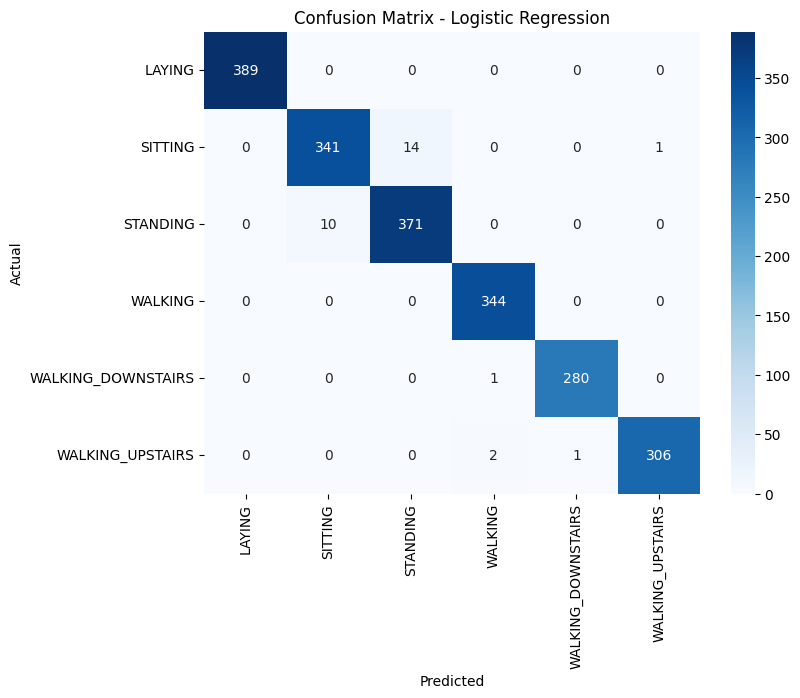

In [30]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [31]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy]
})

results

,Model,Accuracy
0,Logistic Regression,0.985922


In [32]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [33]:
rf_pred = rf.predict(X_test)

In [34]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9825242718446602


In [35]:
print(classification_report(
    y_test,
    rf_pred,
    target_names=encoder.classes_
))

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       389
           SITTING       0.97      0.97      0.97       356
          STANDING       0.97      0.98      0.98       381
           WALKING       1.00      0.98      0.99       344
WALKING_DOWNSTAIRS       0.98      0.98      0.98       281
  WALKING_UPSTAIRS       0.97      0.99      0.98       309

          accuracy                           0.98      2060
         macro avg       0.98      0.98      0.98      2060
      weighted avg       0.98      0.98      0.98      2060



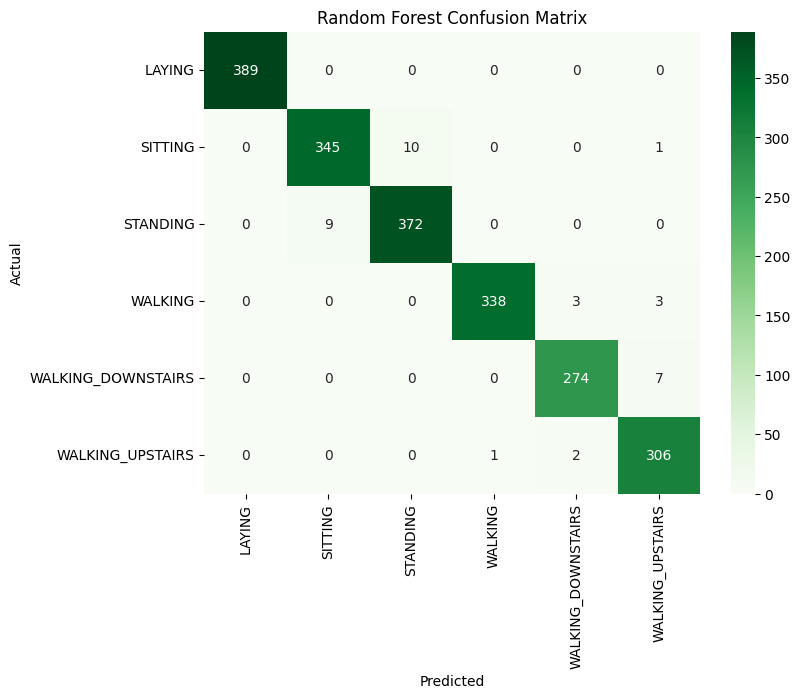

In [36]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [37]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.985922
1,Random Forest,0.982524


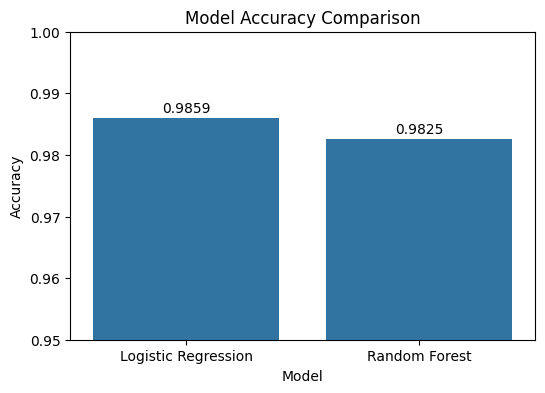

In [38]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0.95, 1.0)
plt.title("Model Accuracy Comparison")

for i, acc in enumerate(results["Accuracy"]):
    plt.text(i, acc + 0.001, f"{acc:.4f}", ha="center")

plt.show()